<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/Larval_Baseline_Physiology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Styling & Setup
Imports the required data science packages and sets the visual fingerprint (fonts, colors, and line weights) so the final plot perfectly matches previous  figures.

In [187]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}
global_box_width = 0.6
global_fig_size = (6, 8)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6

# Centralized Asterisk & Significance Settings
global_asterisk_size = 12
global_asterisk_weight = 'bold'

# Added for significance mapping
def get_significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.005:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

# Added for cleaner look
global_y_nbins = 3
global_edgecolor = 'black'
global_line_width = 1.5

print(f"Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.")

Global styling initialized. Significance mapping (p < 0.05: *, 0.005: **, 0.001: ***) added.


# Release Pattarn by morph

## Block 1: Data Loading & Filtering
We need to load the Release_Data.csv and focus strictly on the HF vs NF comparison, ignoring the 'PF' (if present) to keep the comparison clean.

In [188]:
# Load the data
df = pd.read_csv('Release_Data.csv')

# Focus only on HF and NF for this plot
df_filtered = df[df['morph'].isin(['HF', 'NF'])].copy()

# Print the data to double-check
print("Data Preview:")
print(df_filtered.head())

Data Preview:
  colony morph  total released  % from total coloney
0      A    HF             199             50.636132
2      A    NF              30              7.633588
3      B    HF              23             39.655172
5      B    NF              13             38.235294
6      C    HF             621             29.913295


## Block 3: Normality-Driven Statistical Engine
It checks the distribution of the differences between HF and NF, which is the correct statistical approach for paired data.

In [189]:
# --- BLOCK 3: ROBUST STATISTICAL ANALYSIS ---

# Prepare data for paired comparison (pivot)
df_pivot = df_filtered.pivot_table(index='colony', columns='morph', values='total released')

# 1. Calculate the differences
df_diff = df_pivot[('HF')] - df_pivot[('NF')]

# 2. Shapiro-Wilk Test for Normality on the differences
stat_norm, p_norm = stats.shapiro(df_diff)

print(f"Normality test (Shapiro-Wilk) on paired differences: p = {p_norm:.4f}")

# 3. Decision Logic
if p_norm > 0.05:
    print("Result: Data is normally distributed. Running Paired T-test.")
    stat, p_val = stats.ttest_rel(df_pivot[('HF')],
                                  df_pivot[('NF')])
    test_name = "Paired T-test"
else:
    print("Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.")
    stat, p_val = stats.wilcoxon(df_pivot[('HF')],
                                 df_pivot[('NF')])
    test_name = "Wilcoxon Signed-Rank"

print(f"Selected Test: {test_name}")
print(f"p-value: {p_val:.4f}")

# Store this for the poster visualization
stats_report = f"{test_name}\n p = {p_val:.4f}"

Normality test (Shapiro-Wilk) on paired differences: p = 0.0063
Result: Data is NOT normal. Running Wilcoxon Signed-Rank Test.
Selected Test: Wilcoxon Signed-Rank
p-value: 0.0156


## Plotting

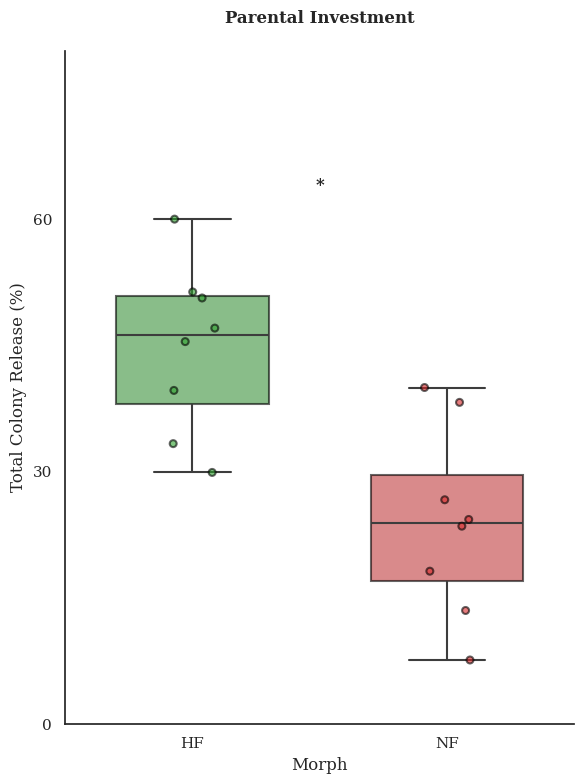

In [190]:

# --- BLOCK: PAIRED RELEASE DATA PLOT (PERCENTAGE) ---

plt.figure(figsize=global_fig_size)

# 1. Boxplot
ax = sns.boxplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    palette=variant_colors,
    hue='morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# 2. Stripplot
sns.stripplot(
    data=df_filtered,
    x='morph',
    y='% from total coloney',
    hue='morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# 3. Dynamic Significance Marker
# Using p_val from Block 3 and the global significance label function
sig_label = get_significance_label(p_val)
plt.text(0.5, df_filtered['% from total coloney'].max() * 1.05,
         sig_label,
         ha='center',
         va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("Parental Investment", fontweight="bold")
plt.ylabel("Total Colony Release (%)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 80)
sns.despine()

plt.tight_layout()
plt.savefig("Morph Release.png", format="png", dpi=600)
plt.show()

# GFP Intensity

## Block 1: Load Data & Outlier Removal
Loading Data and remoiving outliers using the 1.5 IQR method to ensure robust statistical analysis and visualization. This step is performed after initial data loading and filtering.


In [191]:
# Load your data
df = pd.read_csv('GFP_raw_sum_normalized.csv')
# Keep only HF and NF for analysis
df_gfp = df[df['Variant'].isin(['HF', 'NF'])].copy()
print("Data loaded successfully.")

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for 'Intensity_per_µm2'
Q1 = df_gfp['Intensity_per_µm2'].quantile(0.25)
Q3 = df_gfp['Intensity_per_µm2'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
df_gfp_cleaned = df_gfp[(df_gfp['Intensity_per_µm2'] >= lower_bound) & (df_gfp['Intensity_per_µm2'] <= upper_bound)]

print(f"Original number of data points: {len(df_gfp)}")
print(f"Number of data points after outlier removal: {len(df_gfp_cleaned)}")

# Update df_gfp to the cleaned version for subsequent analysis
df_gfp = df_gfp_cleaned.copy()

print("Outliers removed and df_gfp updated.")

Data loaded successfully.
Original number of data points: 21
Number of data points after outlier removal: 21
Outliers removed and df_gfp updated.


## Block 2: Normality Check
It is standard practice to check if your data is normally distributed before choosing a statistical test.

In [192]:
hf_data = df_gfp[df_gfp['Variant'] == 'HF']['Intensity_per_µm2']
nf_data = df_gfp[df_gfp['Variant'] == 'NF']['Intensity_per_µm2']

# Shapiro-Wilk test
stat_hf, p_hf = stats.shapiro(hf_data)
stat_nf, p_nf = stats.shapiro(nf_data)

print(f"Normality Test - HF: p={p_hf:.4f}, NF: p={p_nf:.4f}")

Normality Test - HF: p=0.9369, NF: p=0.0738


## Block 3: Statistical Test
Based on the normality result, we Auto-select the appropriate test.

In [193]:
# Select test: T-test if normal (p > 0.05), Mann-Whitney if not (p < 0.05)
if p_hf < 0.05 or p_nf < 0.05:
    test_type = "Mann-Whitney U"
    stat, p_val = stats.mannwhitneyu(hf_data, nf_data)
else:
    test_type = "Independent T-test"
    stat, p_val = stats.ttest_ind(hf_data, nf_data)

print(f"Test used: {test_type}")
print(f"p-value: {p_val:.4e}")

Test used: Independent T-test
p-value: 1.1467e-08


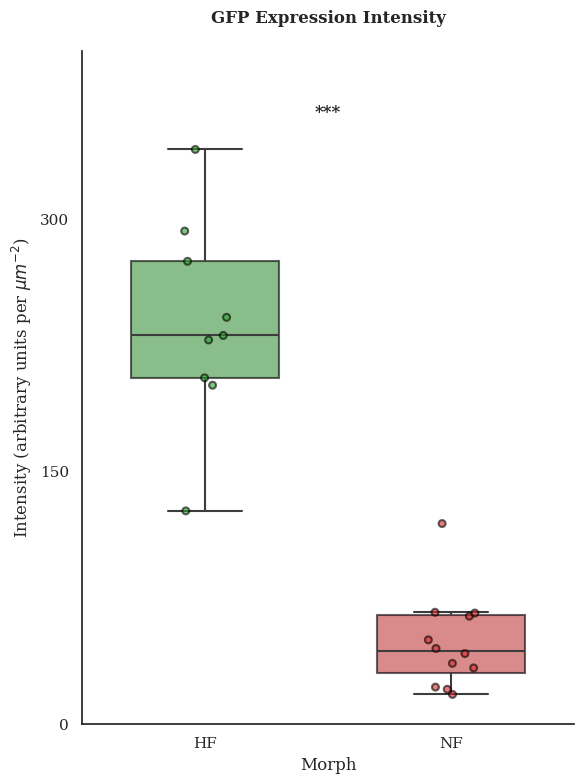

In [194]:
# --- BLOCK: GFP INTENSITY DATA PLOT ---

plt.figure(figsize=global_fig_size)

# 1. Boxplot
ax = sns.boxplot(
    data=df_gfp,
    x='Variant',
    y='Intensity_per_µm2',
    palette=variant_colors,
    hue='Variant',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# 2. Stripplot
sns.stripplot(
    data=df_gfp,
    x='Variant',
    y='Intensity_per_µm2',
    hue='Variant',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# 3. Dynamic Significance Marker
sig_label = get_significance_label(p_val)
plt.text(0.5, df_gfp['Intensity_per_µm2'].max() * 1.05,
         sig_label,
         ha='center',
         va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("GFP Expression Intensity", fontweight="bold")
plt.ylabel(r"Intensity (arbitrary units per $\mu m^{-2}$)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 400)
sns.despine()
plt.tight_layout()
plt.savefig("GFP_Intensity_Plot.png", format="png", dpi=600)
plt.show()

# Planulae Volume

## Block 1: Setup & Load 2026 Data
loads dataset, stripping any hidden spaces from the columns.

In [195]:

# 1. Load 2026 Data
file_2026 = 'Planulae size 2026.csv'
df26 = pd.read_csv(file_2026, encoding='latin-1')
df26.columns = df26.columns.str.strip()


## Block 2: Geometric Filtering
Recalculate the dimensions from your ImageJ Area and Perimeter outputs to filter out any planulae that were imaged horizontally (Aspect Ratio < 2.5).

In [196]:
# 2. Geometric Filtering (Aspect Ratio >= 2.5)
A = df26['area µm²']
P = df26['perimeter µm']
r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
w = 2 * r
L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
df26['Aspect_Ratio'] = L_total / w

# Split data into removed vs good
df26_removed_ratio = df26[df26['Aspect_Ratio'] < 2.5]
df26_good = df26[df26['Aspect_Ratio'] >= 2.5].copy()

## Block 3: Remove 1.5 IQR Outliers
This sweeps the dataset to find any extreme volume measurements per morphotype (HF vs. NF).

In [197]:
# 3. Remove 1.5 IQR outliers per group
def remove_outliers(df, group_col, val_col):
    outliers_list = []
    clean_data_list = []

    for name, group in df.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter rows
        outliers = group[(group[val_col] < lower_bound) | (group[val_col] > upper_bound)]
        clean = group[(group[val_col] >= lower_bound) & (group[val_col] <= upper_bound)]

        outliers_list.append(outliers)
        clean_data_list.append(clean)

    return pd.concat(clean_data_list), pd.concat(outliers_list)

# Apply filter specifically to Volume
df26_clean, df26_outliers = remove_outliers(df26_good, 'morph', 'Volume mm³')

# Print Data Removal Report
print("--- 2026 DATA REMOVAL REPORT ---")
print(f"Total larvae ignored due to Aspect Ratio < 2.5: {len(df26_removed_ratio)}")
if not df26_removed_ratio.empty:
    print(df26_removed_ratio[['no', 'morph', 'Label', 'Aspect_Ratio']])
print("-" * 40)

print(f"Total outliers removed (1.5 IQR): {len(df26_outliers)}")
if not df26_outliers.empty:
    print(df26_outliers[['no', 'morph', 'Label', 'Volume mm³']])
print("-" * 40)
print(f"Total larvae remaining for analysis: {len(df26_clean)}")

--- 2026 DATA REMOVAL REPORT ---
Total larvae ignored due to Aspect Ratio < 2.5: 4
      no morph  Label  Aspect_Ratio
50    51    HF      1      1.783012
81    82    HF     11      2.254283
94    95    NF      2      2.248411
101  102    NF      4      1.653646
----------------------------------------
Total outliers removed (1.5 IQR): 9
      no morph  Label  Volume mm³
5      6    HF      2      0.4590
8      9    HF      1      0.4795
12    13    HF      2      0.4758
14    15    HF      2      0.4609
16    17    HF      2      0.1601
24    25    HF      3      0.1490
48    49    HF      5      0.5298
54    55    HF      5      0.4530
109  110    NF      2      0.4689
----------------------------------------
Total larvae remaining for analysis: 125


## Block 4: Normality Test
Evaluates if the volume distribution of HF and NF cohorts follow a normal Gaussian curve using the Shapiro-Wilk test.

In [198]:
# 5. Normality Test & Diagnostic Plots
import matplotlib.ticker as ticker

unique_morphs = df26_clean['morph'].unique()
print("\n--- 2026 NORMALITY TEST (Cleaned Data) ---")
normality_results = {}


for i, morph in enumerate(unique_morphs):
    data = df26_clean[df26_clean['morph'] == morph]['Volume mm³'].dropna()

    # Statistical Test
    shapiro_p = stats.shapiro(data)[1]
    is_normal = shapiro_p > 0.05
    normality_results[morph] = is_normal

    result = "Normal ✅" if is_normal else "NOT Normal ❌"
    print(f"Morph: {morph} (n={len(data)}) | Shapiro-Wilk p-value: {shapiro_p:.5f} | {result}")




--- 2026 NORMALITY TEST (Cleaned Data) ---
Morph: HF (n=82) | Shapiro-Wilk p-value: 0.96090 | Normal ✅
Morph: NF (n=43) | Shapiro-Wilk p-value: 0.66581 | Normal ✅


## Block 5: Automated Statistical Decision & Summary
Automatically reads the output of Block 5. If both groups are normal, it runs a T-test; if either group is skewed, it defaults to the non-parametric Mann-Whitney U test.

In [199]:
# 5. Statistical test based on normality & 7. Full statistical summary
print("\n--- STATISTICAL COMPARISON SUMMARY ---")
morphs = list(normality_results.keys())

if len(morphs) == 2:
    group1 = df26_clean[df26_clean['morph'] == morphs[0]]['Volume mm³'].dropna()
    group2 = df26_clean[df26_clean['morph'] == morphs[1]]['Volume mm³'].dropna()

    # Logic gate for stats
    if all(normality_results.values()):
        print("Verdict: Both groups are normally distributed.")
        stat, p_val = stats.ttest_ind(group1, group2)
        test_used = "Independent T-test"
    else:
        print("Verdict: Non-normal distribution detected.")
        stat, p_val = stats.mannwhitneyu(group1, group2)
        test_used = "Mann-Whitney U"

    significance = "Significant ⭐" if p_val < 0.05 else "Not Significant (NS)"

    # 7. Summary
    print(f"\nComparison: {morphs[0]} vs {morphs[1]}")
    print(f"Test Used: {test_used}")
    print(f"Statistic: {stat:.5f}")
    print(f"p-value: {p_val:.5e} | {significance}")
else:
    print("More than 2 morphs detected. Code requires adjustment for ANOVA/Kruskal-Wallis.")


--- STATISTICAL COMPARISON SUMMARY ---
Verdict: Both groups are normally distributed.

Comparison: HF vs NF
Test Used: Independent T-test
Statistic: 3.00522
p-value: 3.21720e-03 | Significant ⭐


## Block 8: Global Style Plotting
Creates a publication-ready figure Boxplot with jittered dots to show the exact spread of HF vs. NF volume.

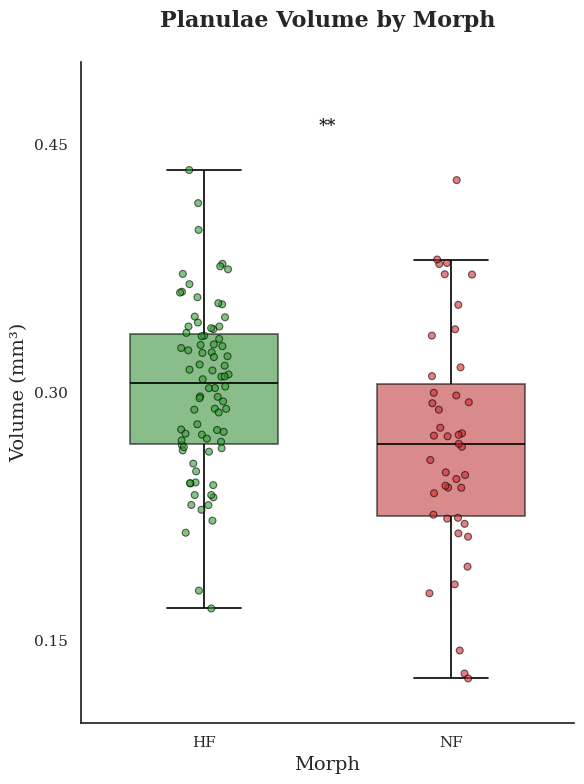

In [200]:
fig, ax_box = plt.subplots(figsize=global_fig_size)

plot_order = [m for m in ['HF', 'NF'] if m in df26_clean['morph'].unique()]

# Main comparison plot
sns.boxplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    ax=ax_box,
    showfliers=False,
    legend=False,
    width=global_box_width,
    boxprops=dict(edgecolor="black", linewidth=1.2, alpha=0.6),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.2)
)

# Jittered points
sns.stripplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    alpha=global_alpha,
    jitter=global_jitter,
    size=global_marker_size,
    ax=ax_box,
    legend=False,
    linewidth=0.8,
    edgecolor='black'
)

# --- SIGNIFICANCE ANNOTATION (using global function) ---
if 'p_val' in globals():
    sig_str = get_significance_label(p_val)

    if sig_str != 'n.s.':
        x1, x2 = 0, 1
        y_max = df26_clean['Volume mm\u00b3'].max()
        h_ast = y_max * 1.05
        ax_box.text((x1+x2)*.5, h_ast, sig_str,
                    ha='center', va='bottom',
                    fontsize=global_asterisk_size,
                    fontweight=global_asterisk_weight)

# Labels and Ticks
ax_box.set_title("Planulae Volume by Morph", fontsize=16, fontweight=global_asterisk_weight, pad=25)
ax_box.set_ylabel("Volume (mm\u00b3)", fontsize=14)
ax_box.set_xlabel("Morph", fontsize=14)
ax_box.set_ylim(0.1, 0.5)
ax_box.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

sns.despine()
plt.tight_layout()

# Save the plot at 600 DPI
plt.savefig("Planulae_Volume_Plot.png", format="png", dpi=600)

plt.show()

# Respiration Rate

## Block 1: Loading Data and combining expirimantal loadout with Oxygen raw data

In [201]:
import pandas as pd
import numpy as np
from scipy.stats import linregress

# 1. Load data files securely using the Latin1 text layout decoder
df_oxy = pd.read_csv('oxy16042026_Oxygen.csv', encoding='latin1')
df_load = pd.read_csv('loadout.csv', encoding='latin1')

# 2. Convert the 2D loadout grid template into a flat coordinate map
df_load = df_load.set_index('Unnamed: 0')
well_morph_lookup = {}

for row_letter in df_load.index:
    for col_number in ['1', '2', '3', '4', '5', '6']:
        well_coordinate = f"{row_letter}{col_number}"
        morphtype = df_load.loc[row_letter, col_number]
        well_morph_lookup[well_coordinate] = morphtype

# 3. Target all possible well channels across the 24-well configuration plate
target_channels = [f"{r}{c}" for r in ['A', 'B', 'C', 'D'] for c in range(1, 7)]
compiled_dataset = []

# 4. Loop through each target channel, isolate values, and process active rates
for channel in target_channels:
    if channel in df_oxy.columns:
        # Isolate the targeted timeline slice and scrub empty cells
        data_slice = df_oxy[['Time/Min.', channel]].dropna()

        # Enforce strict float properties to block text parsing anomalies
        time_data = pd.to_numeric(data_slice['Time/Min.'], errors='coerce')
        oxy_data = pd.to_numeric(data_slice[channel], errors='coerce')

        # Clean out any remaining missing values after conversion
        valid_indices = time_data.notna() & oxy_data.notna()
        time_clean = time_data[valid_indices]
        oxy_clean = oxy_data[valid_indices]

        if len(time_clean) > 1:
            # Perform ordinary least squares regression
            slope, intercept, r_value, p_value, std_err = linregress(time_clean, oxy_clean)

            # Append rows, inverting the rate slope parameter into consumption speed
            compiled_dataset.append({
                'Well': channel,
                'Morph': well_morph_lookup.get(channel, 'Unknown'),
                'Respiration_Rate_umol_L_min': -slope,
                'R_Squared': r_value ** 2
            })

# 5. Build the clean, long-format final dataframe structure
df_planula_respiration = pd.DataFrame(compiled_dataset)

# 6. Display primary processing metrics directly inside the workspace window
print("--- FIRST 10 INTEGRATED SAMPLES ---")
print(df_planula_respiration.head(10).to_string(index=False))

print("\n--- GLOBAL AGGREGATED SUMMARY LOGS ---")
summary = df_planula_respiration.groupby('Morph')['Respiration_Rate_umol_L_min'].agg(['count', 'mean', 'std', 'min', 'max'])
print(summary)

# 7. Export the final long-format output structure to your workspace directory
df_planula_respiration.to_csv('Planula_Baseline_Respiration_Processed.csv', index=False)

--- FIRST 10 INTEGRATED SAMPLES ---
Well Morph  Respiration_Rate_umol_L_min  R_Squared
  A1    HF                     0.404921   0.958150
  A2    HF                     1.013406   0.976984
  A3    HF                     1.144284   0.986136
  A4    NF                     1.598505   0.982093
  A5    NF                     1.862354   0.973296
  A6 blank                    -0.023313   0.389262
  B1    HF                     1.188499   0.966387
  B2    HF                     1.474413   0.980757
  B3    HF                     1.518870   0.978700
  B4    NF                     1.798730   0.991471

--- GLOBAL AGGREGATED SUMMARY LOGS ---
       count      mean       std       min       max
Morph                                               
HF        10  1.501288  0.804601  0.404921  3.142877
NF        10  1.636851  0.596712  0.727637  2.936219
blank      4  0.002226  0.044015 -0.023313  0.067945


## Block 2: Substracting Avarge Blank From all Samples


In [202]:
import pandas as pd

# 1. Calculate the mean respiration rate of the blanks
blank_avg = df_planula_respiration[df_planula_respiration['Morph'] == 'blank']['Respiration_Rate_umol_L_min'].mean()
print(f"Average Blank Respiration Rate (Baseline): {blank_avg:.6f} umol/L/min")

# 2. Correct for baseline and divide by 3 (since there are 3 planulae per well)
# This gives us the rate per individual planula
df_planula_respiration['Corrected_Respiration_Rate_per_Planula'] = (df_planula_respiration['Respiration_Rate_umol_L_min'] - blank_avg) / 3

# 3. Filter to keep only experimental samples (removing blanks) for analysis
df_respiration_corrected = df_planula_respiration[df_planula_respiration['Morph'] != 'blank'].copy()

# 4. Display the updated summary
print("\n--- GLOBAL AGGREGATED SUMMARY (RATE PER PLANULA) ---")
summary_corrected = df_respiration_corrected.groupby('Morph')['Corrected_Respiration_Rate_per_Planula'].agg(['count', 'mean', 'std', 'min', 'max'])
display(summary_corrected)

# 5. Export the corrected data
df_respiration_corrected.to_csv('Planula_Respiration_Corrected.csv', index=False)

Average Blank Respiration Rate (Baseline): 0.002226 umol/L/min

--- GLOBAL AGGREGATED SUMMARY (RATE PER PLANULA) ---


,count,mean,std,min,max
Morph,,,,,
HF,10,0.499687,0.268200,0.134232,1.046884
NF,10,0.544875,0.198904,0.241803,0.977998


## Block 3: Normelizing Raspiration Rate by Volume

In [203]:
# --- BLOCK: VOLUME-SPECIFIC RESPIRATION NORMALIZATION ---

# 1. Calculate average volume per morph from the cleaned 2026 volume data
avg_volume = df26_clean.groupby('morph')['Volume mm³'].mean()
print("Average Volume per Morph (mm³):")
print(avg_volume)

# 2. Map these volumes to the respiration dataframe and divide
df_respiration_corrected['Avg_Morph_Volume_mm3'] = df_respiration_corrected['Morph'].map(avg_volume)
df_respiration_corrected['Respiration_Rate_per_mm3'] = (
    df_respiration_corrected['Corrected_Respiration_Rate_per_Planula'] / df_respiration_corrected['Avg_Morph_Volume_mm3']
)

# 3. Display updated summary
print("\n--- SUMMARY: RESPIRATION RATE PER VOLUME (umol/L/min/mm3) ---")
vol_summary = df_respiration_corrected.groupby('Morph')['Respiration_Rate_per_mm3'].agg(['count', 'mean', 'std'])
display(vol_summary)

Average Volume per Morph (mm³):
morph
HF    0.302380
NF    0.269826
Name: Volume mm³, dtype: float64

--- SUMMARY: RESPIRATION RATE PER VOLUME (umol/L/min/mm3) ---


,count,mean,std
Morph,,,
HF,10,1.652512,0.886964
NF,10,2.019360,0.737158


## Block 4: Removing Outliers X1.5IQR


In [204]:
def remove_respiration_outliers(df, group_col, val_col):
    clean_list = []
    outlier_list = []
    for name, group in df.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = group[(group[val_col] < lower) | (group[val_col] > upper)]
        clean = group[(group[val_col] >= lower) & (group[val_col] <= upper)]

        clean_list.append(clean)
        outlier_list.append(outliers)
    return pd.concat(clean_list), pd.concat(outlier_list)

# Apply to volume-specific respiration rate
df_resp_final, df_resp_outliers = remove_respiration_outliers(df_respiration_corrected, 'Morph', 'Respiration_Rate_per_mm3')

print("--- RESPIRATION OUTLIER REPORT ---")
print(f"Outliers removed: {len(df_resp_outliers)}")
if not df_resp_outliers.empty:
    display(df_resp_outliers[['Well', 'Morph', 'Respiration_Rate_per_mm3']])
print(f"Samples remaining: {len(df_resp_final)}")

--- RESPIRATION OUTLIER REPORT ---
Outliers removed: 4


,Well,Morph,Respiration_Rate_per_mm3
0,A1,HF,0.443916
12,C1,HF,3.462140
13,C2,HF,2.913233
14,C3,NF,3.624555


Samples remaining: 16


## Block 5: Normality check


In [205]:
# --- BLOCK: NORMALITY TEST FOR CLEANED RESPIRATION ---

# 1. Isolate the final cleaned groups
hf_final_vals = df_resp_final[df_resp_final['Morph'] == 'HF']['Respiration_Rate_per_mm3']
nf_final_vals = df_resp_final[df_resp_final['Morph'] == 'NF']['Respiration_Rate_per_mm3']

# 2. Shapiro-Wilk Test
stat_hf_f, p_hf_final = stats.shapiro(hf_final_vals)
stat_nf_f, p_nf_final = stats.shapiro(nf_final_vals)

print(f"--- FINAL NORMALITY TEST (n={len(df_resp_final)}) ---")
print(f"HF Morph (n={len(hf_final_vals)}): p = {p_hf_final:.4f} {'(Normal)' if p_hf_final > 0.05 else '(NOT Normal)'}")
print(f"NF Morph (n={len(nf_final_vals)}): p = {p_nf_final:.4f} {'(Normal)' if p_nf_final > 0.05 else '(NOT Normal)'}")

--- FINAL NORMALITY TEST (n=16) ---
HF Morph (n=7): p = 0.5082 (Normal)
NF Morph (n=9): p = 0.2786 (Normal)


## Block 6: Plotting

--- FINAL STATISTICAL RESULT ---
Test: Independent T-test
p-value: 0.0426


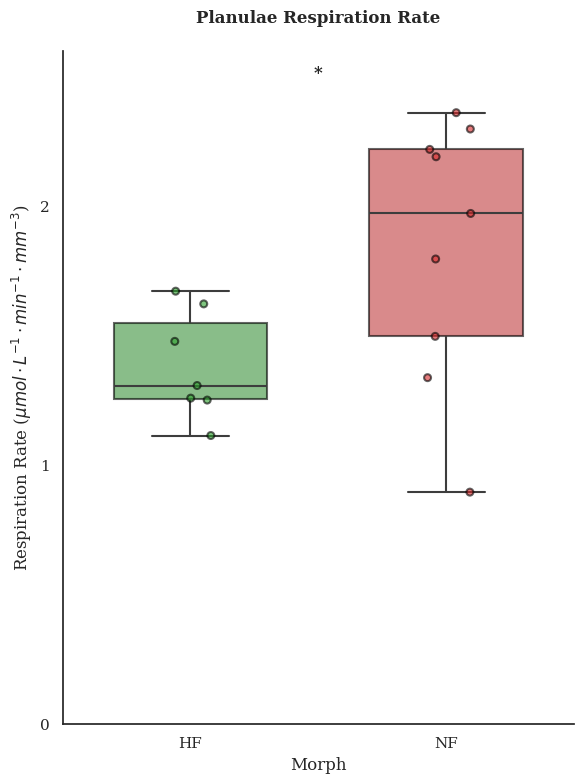

In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Perform Independent T-test since both groups are normal
stat_final, p_val_final = stats.ttest_ind(hf_final_vals, nf_final_vals)

print(f"--- FINAL STATISTICAL RESULT ---")
print(f"Test: Independent T-test")
print(f"p-value: {p_val_final:.4f}")

# 2. Plotting with Global Styles
plt.figure(figsize=global_fig_size)

# Boxplot
ax = sns.boxplot(
    data=df_resp_final,
    x='Morph',
    y='Respiration_Rate_per_mm3',
    palette=variant_colors,
    hue='Morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# Stripplot
sns.stripplot(
    data=df_resp_final,
    x='Morph',
    y='Respiration_Rate_per_mm3',
    hue='Morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# Significance Label
sig_label = get_significance_label(p_val_final)
y_max = df_resp_final['Respiration_Rate_per_mm3'].max()
plt.text(0.5, y_max * 1.05,
         sig_label,
         ha='center', va='bottom',
         fontsize=global_asterisk_size,
         fontweight=global_asterisk_weight)

# Final Touches
plt.title("Planulae Respiration Rate", fontweight="bold")
# Corrected LaTeX label: single backslash inside a raw string for Matplotlib math
plt.ylabel(r"Respiration Rate ($\mu mol \cdot L^{-1} \cdot min^{-1} \cdot mm^{-3}$)")
plt.xlabel("Morph")
ax.yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
plt.ylim(0, 2.6)
sns.despine()
plt.tight_layout()
plt.savefig("Respiration_Rate_Final_Cleaned.png", dpi=600)
plt.show()

# Larval Protein Density

## Block 1: Load Protein Data & Merge with Volume
We will load the protein concentration data ($μg/ml$) and associate it with the average morph volumes calculated in the previous 'Planulae Volume' section.

In [207]:
import pandas as pd

# 1. Load protein data
df_prot = pd.read_csv('liel12012026_562.csv', encoding='latin1')

# 2. Cleanup: Strip whitespace and drop empty rows
df_prot.columns = df_prot.columns.str.strip()
df_prot = df_prot.dropna(subset=['morph']).copy()
df_prot['morph'] = df_prot['morph'].str.strip()

# --- Show number of samples loaded ---
print(f"Total valid samples loaded: {len(df_prot)}")
print(df_prot.groupby('morph').size())

# 3. Map average volumes from the Planulae Volume section
df_prot['Avg_Volume_mm3'] = df_prot['morph'].map(avg_volume)

# 4. Recalculate protein density using absolute protein per larva divided by individual morph volume
# Calculation: (ug/ml per larva) / (Avg Morph Volume mm3) = ug/mm3
df_prot['Protein_Density_ug_mm3'] = df_prot['ug/ml per larvae'] / df_prot['Avg_Volume_mm3']

print("\n--- Average Volumes Used for Calculation (mm3) ---")
display(avg_volume)

print("\n--- PROTEIN DATA PREVIEW (Corrected Logic: Per Larva / Volume) ---")
display(df_prot[['vile no', 'morph', 'ug/ml per larvae', 'Protein_Density_ug_mm3']].head())

print("\n--- PROTEIN DENSITY SUMMARY (Initial) ---")
prot_summary = df_prot.groupby('morph')['Protein_Density_ug_mm3'].agg(['count', 'mean', 'std'])
display(prot_summary)

Total valid samples loaded: 11
morph
HF    5
NF    6
dtype: int64

--- Average Volumes Used for Calculation (mm3) ---


,Volume mm³
morph,
HF,0.302380
NF,0.269826



--- PROTEIN DATA PREVIEW (Corrected Logic: Per Larva / Volume) ---


,vile no,morph,ug/ml per larvae,Protein_Density_ug_mm3
0,1,NF,39.906,147.895540
1,2,NF,46.677,172.989528
2,3,NF,45.361,168.112303
3,4,NF,38.565,142.925663
4,5,NF,34.017,126.070330



--- PROTEIN DENSITY SUMMARY (Initial) ---


,count,mean,std
morph,,,
HF,5,151.906627,10.520965
NF,6,156.863061,21.458392


## Block 2: Outlier Removal
Applying the 1.5 IQR method to ensure the protein density comparison is robust.

In [208]:
# --- BLOCK 2: UPDATED OUTLIER REMOVAL ---
def remove_prot_outliers(df, group_col, val_col):
    clean_list = []
    outlier_list = []
    print("--- OUTLIER CALCULATION LOGIC (1.5 IQR Rule) ---")

    df_subset = df.dropna(subset=[val_col, group_col])
    for name, group in df_subset.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        print(f"\nMorph: {name}")
        print(f"  - Lower Fence: {lower_fence:.2f}, Upper Fence: {upper_fence:.2f}")

        clean = group[(group[val_col] >= lower_fence) & (group[val_col] <= upper_fence)]
        outliers = group[(group[val_col] < lower_fence) | (group[val_col] > upper_fence)]

        clean_list.append(clean)
        outlier_list.append(outliers)

    return pd.concat(clean_list), pd.concat(outlier_list)

df_prot_clean, df_prot_removed = remove_prot_outliers(df_prot, 'morph', 'Protein_Density_ug_mm3')

# --- Formatting: Remove decimal from vile no, sort, and match index ---
df_prot_clean['vile no'] = df_prot_clean['vile no'].astype(int)
df_prot_clean = df_prot_clean.sort_values('vile no').set_index('vile no', drop=False)

if not df_prot_removed.empty:
    df_prot_removed['vile no'] = df_prot_removed['vile no'].astype(int)
    df_prot_removed = df_prot_removed.sort_values('vile no').set_index('vile no', drop=False)

print("\n--- PROTEIN OUTLIER SUMMARY ---")
print(f"Samples remaining: {len(df_prot_clean)}")
if not df_prot_removed.empty:
    display(df_prot_removed[['vile no', 'morph', 'ug/ml per larvae', 'Protein_Density_ug_mm3']])

print("\n--- FULL CLEANED DATAFRAME ---")
display(df_prot_clean[['vile no', 'morph', 'ug/ml per larvae', 'Protein_Density_ug_mm3']])

--- OUTLIER CALCULATION LOGIC (1.5 IQR Rule) ---

Morph: HF
  - Lower Fence: 127.48, Upper Fence: 173.13

Morph: NF
  - Lower Fence: 102.76, Upper Fence: 213.17

--- PROTEIN OUTLIER SUMMARY ---
Samples remaining: 11

--- FULL CLEANED DATAFRAME ---


,vile no,morph,ug/ml per larvae,Protein_Density_ug_mm3
vile no,,,,
1,1,NF,39.906,147.895540
2,2,NF,46.677,172.989528
3,3,NF,45.361,168.112303
4,4,NF,38.565,142.925663
5,5,NF,34.017,126.070330
6,6,NF,49.428,183.185003
7,7,HF,50.556,167.193328
8,8,HF,45.841,151.600390
9,9,HF,47.175,156.012051


## Block 3: Normality Check
We evaluate the distribution of the cleaned protein density data for both HF and NF groups to determine the appropriate statistical test.

In [209]:
# --- BLOCK 3: UPDATED NORMALITY TEST ---
hf_prot = df_prot_clean[df_prot_clean['morph'] == 'HF']['Protein_Density_ug_mm3']
nf_prot = df_prot_clean[df_prot_clean['morph'] == 'NF']['Protein_Density_ug_mm3']

stat_hf, p_hf = stats.shapiro(hf_prot)
stat_nf, p_nf = stats.shapiro(nf_prot)

print(f"--- PROTEIN DENSITY NORMALITY TEST (Corrected Logic) ---")
print(f"HF Morph (n={len(hf_prot)}): p = {p_hf:.4f}")
print(f"NF Morph (n={len(nf_prot)}): p = {p_nf:.4f}")

--- PROTEIN DENSITY NORMALITY TEST (Corrected Logic) ---
HF Morph (n=5): p = 0.8867
NF Morph (n=6): p = 0.7986


## Block 4: Statistical Comparison & Visualization
Based on the normality results, we perform the final comparison and generate the figure.


Selected Test: Independent T-test, p = 0.6504


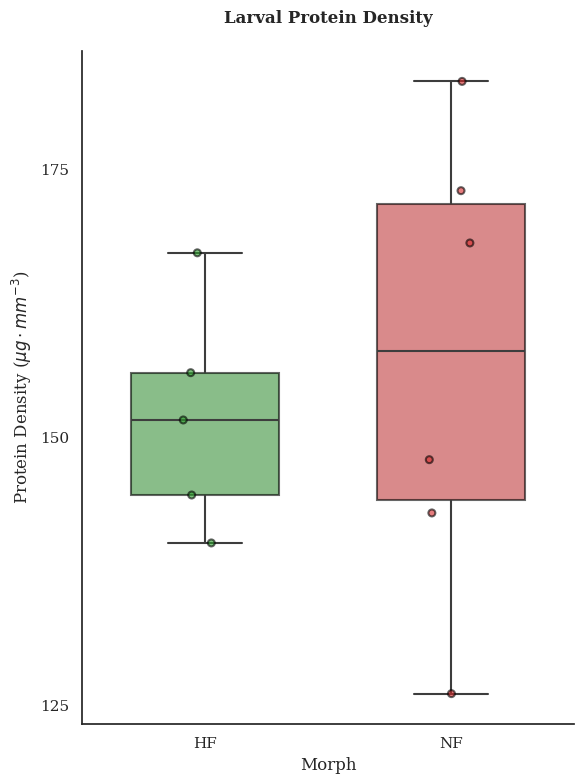

In [210]:
# --- BLOCK 4: UPDATED STATS & PLOTTING ---
if p_hf > 0.05 and p_nf > 0.05:
    test_name = "Independent T-test"
    stat, p_val = stats.ttest_ind(hf_prot, nf_prot)
else:
    test_name = "Mann-Whitney U"
    stat, p_val = stats.mannwhitneyu(hf_prot, nf_prot)

print(f"\nSelected Test: {test_name}, p = {p_val:.4f}")

plt.figure(figsize=global_fig_size)

# Set explicit order to put HF on the left
plot_order = ['HF', 'NF']

# Boxplot
ax = sns.boxplot(
    data=df_prot_clean,
    x='morph',
    y='Protein_Density_ug_mm3',
    order=plot_order,
    palette=variant_colors,
    hue='morph',
    width=global_box_width,
    showfliers=False,
    linewidth=global_line_width,
    legend=False,
    boxprops={'alpha': global_alpha, 'edgecolor': global_edgecolor}
)

# Stripplot
sns.stripplot(
    data=df_prot_clean,
    x='morph',
    y='Protein_Density_ug_mm3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    size=global_marker_size,
    jitter=global_jitter,
    alpha=global_alpha,
    zorder=5,
    legend=False,
    edgecolor=global_edgecolor,
    linewidth=global_line_width
)

# Dynamic Significance Marker - Modified to hide 'n.s.'
sig_label = get_significance_label(p_val)
if sig_label != 'n.s.':
    y_max = df_prot_clean['Protein_Density_ug_mm3'].max()
    plt.text(0.5, y_max * 1.05, sig_label, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

plt.title("Larval Protein Density", fontweight="bold")
plt.ylabel(r"Protein Density ($\mu g \cdot mm^{-3}$)")
plt.xlabel("Morph")
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(global_y_nbins))
sns.despine()
plt.tight_layout()
plt.savefig("Larval_Protein_Density_Corrected.png", dpi=600)
plt.show()

# Symbionts Cell Count